# Notebook de Training de ambos modelos
Se corren ambos modelos 4 veces cada uno. Con cada función de pérdida. Se guardan los logs de cada corrida. Los resultados son guardados y accesados por medio de WanDB.

Se corre localmente con GPU, se verifica instalación correcta de CUDA para PyTorch

In [1]:
!python -c "import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"


True
NVIDIA GeForce GTX 1650


Instalación de dependencias para el .venv local

In [1]:
!python -m pip install --upgrade pip

!python -m pip install torch==2.11.0 torchvision==0.26.0 --index-url https://download.pytorch.org/whl/cu130
!python -m pip install hydra-core lightning pytorch-lightning wandb torchmetrics matplotlib scikit-learn pandas seaborn tqdm


  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/1.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 GB 36.6 MB/s eta 0:00:53
   ---------------------------------------- 0.0/1.9 GB 30.8 MB/s eta 0:01:02
   ---------------------------------------- 0.0/1.9 GB 26.5 MB/s eta 0:01:12
   ---------------------------------------- 0.0/1.9 GB 25.7 MB/s e

wandb login

In [1]:
!python -c "import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"
!wandb login

True
NVIDIA GeForce GTX 1650


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\antho\_netrc.
wandb: Currently logged in as: anthonyguevara2004 (anthonyguevara2004-tecnologico-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Se corren los 8 experimentos en bloque

In [5]:
from pathlib import Path
import subprocess
import sys
import datetime

runs = [
    ("vae", "l1"),
    ("vae", "l2"),
    ("vae", "ssim"),
    ("vae", "ssim+l1"),
    ("u-net", "l1"),
    ("u-net", "l2"),
    ("u-net", "ssim"),
    ("u-net", "ssim+l1"),
]

log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

for model, loss in runs:
    name = f"{model}_{loss}_gpu20"
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = log_dir / f"{name}_{timestamp}.log"

    cmd = [
        sys.executable,
        "train.py",
        f"model={model}",
        f"model.loss_type={loss}",
        "trainer.accelerator=gpu",
        "trainer.devices=1",
        f"logger.name={name}",
    ]

    print(f"\nRunning: {name}")
    print(f"Log: {log_path}")

    with log_path.open("w", encoding="utf-8", errors="replace") as f:
        f.write(f"Run: {name}\n")
        f.write(f"Command: {' '.join(cmd)}\n\n")
        f.flush()

        result = subprocess.run(
            cmd,
            stdout=f,
            stderr=subprocess.STDOUT,
            text=True,
        )

    if result.returncode != 0:
        print(f"Failed: {name}. Check {log_path}")
        break

    print(f"Finished: {name}")


Running: vae_l1_gpu20
Log: logs\vae_l1_gpu20_20260526_102838.log
Finished: vae_l1_gpu20

Running: vae_l2_gpu20
Log: logs\vae_l2_gpu20_20260526_103743.log
Finished: vae_l2_gpu20

Running: vae_ssim_gpu20
Log: logs\vae_ssim_gpu20_20260526_104615.log
Finished: vae_ssim_gpu20

Running: vae_ssim+l1_gpu20
Log: logs\vae_ssim+l1_gpu20_20260526_105412.log
Finished: vae_ssim+l1_gpu20

Running: u-net_l1_gpu20
Log: logs\u-net_l1_gpu20_20260526_110236.log
Finished: u-net_l1_gpu20

Running: u-net_l2_gpu20
Log: logs\u-net_l2_gpu20_20260526_111032.log
Finished: u-net_l2_gpu20

Running: u-net_ssim_gpu20
Log: logs\u-net_ssim_gpu20_20260526_111810.log
Finished: u-net_ssim_gpu20

Running: u-net_ssim+l1_gpu20
Log: logs\u-net_ssim+l1_gpu20_20260526_112618.log
Finished: u-net_ssim+l1_gpu20


# Resultados de los experimentos

Se busca y se visualizan los resultados de cada corrida. 

In [10]:
import wandb
import pandas as pd

api = wandb.Api()

ENTITY = "anthonyguevara2004-tecnologico-costa-rica"
PROJECT = "tarea-03-autoencoders"

runs = api.runs(f"{ENTITY}/{PROJECT}")

target_runs = [
    "vae_l1_gpu20",
    "vae_l2_gpu20",
    "vae_ssim_gpu20",
    "vae_ssim+l1_gpu20",
    "u-net_l1_gpu20",
    "u-net_l2_gpu20",
    "u-net_ssim_gpu20",
    "u-net_ssim+l1_gpu20",
]


def extract_model_and_loss(run, config):
    config_dict = config.as_dict() if hasattr(config, "as_dict") else dict(config)

    nested_model = config_dict.get("model", {})
    if not isinstance(nested_model, dict):
        nested_model = {}

    model_name = nested_model.get("name") or config_dict.get("model.name")
    loss_type = nested_model.get("loss_type") or config_dict.get("model.loss_type")

    if model_name is None or loss_type is None:
        run_root, maybe_loss, _ = run.name.rsplit("_", 2)
        if model_name is None:
            model_name = run_root
        if loss_type is None:
            loss_type = maybe_loss

    return model_name, loss_type


rows = []

for run in runs:
    if run.name in target_runs:
        summary = run.summary._json_dict
        model_name, loss_type = extract_model_and_loss(run, run.config)

        rows.append({
            "run": run.name,
            "model": model_name,
            "loss_type": loss_type,
            "train/loss": summary.get("train/loss"),
            "train/recon_loss": summary.get("train/recon_loss"),
            "train/kl_loss": summary.get("train/kl_loss"),
            "val/loss": summary.get("val/loss"),
            "val/recon_loss": summary.get("val/recon_loss"),
            "val/kl_loss": summary.get("val/kl_loss"),
            "test/loss": summary.get("test/loss"),
            "test/recon_loss": summary.get("test/recon_loss"),
            "test/kl_loss": summary.get("test/kl_loss"),
            "epoch": summary.get("epoch"),
        })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(["model", "loss_type"]).reset_index(drop=True)
df_results

,run,model,loss_type,train/loss,train/recon_loss,train/kl_loss,val/loss,val/recon_loss,val/kl_loss,test/loss,test/recon_loss,test/kl_loss,epoch
0,u-net_l1_gpu20,u-net,l1,0.025172,NaN,NaN,0.036483,NaN,NaN,0.036575,NaN,NaN,20
1,u-net_l2_gpu20,u-net,l2,0.000844,NaN,NaN,0.000714,NaN,NaN,0.000725,NaN,NaN,20
2,u-net_ssim_gpu20,u-net,ssim,0.023510,NaN,NaN,0.019539,NaN,NaN,0.020001,NaN,NaN,20
3,u-net_ssim+l1_gpu20,u-net,ssim+l1,0.049507,NaN,NaN,0.035971,NaN,NaN,0.037039,NaN,NaN,20
4,vae_l1_gpu20,vae,l1,0.048867,0.042446,64.211067,0.056102,0.049999,61.027161,0.059594,0.053636,59.573788,20
5,vae_l2_gpu20,vae,l2,0.010780,0.007123,36.571884,0.010596,0.006949,36.472244,0.011497,0.007936,35.614429,20
6,vae_ssim_gpu20,vae,ssim,0.285226,0.270023,152.036377,0.280623,0.268630,119.929756,0.297947,0.286116,118.315155,20
7,vae_ssim+l1_gpu20,vae,ssim+l1,0.389988,0.354324,356.638824,0.383685,0.354139,295.459137,0.407393,0.377905,294.886292,20


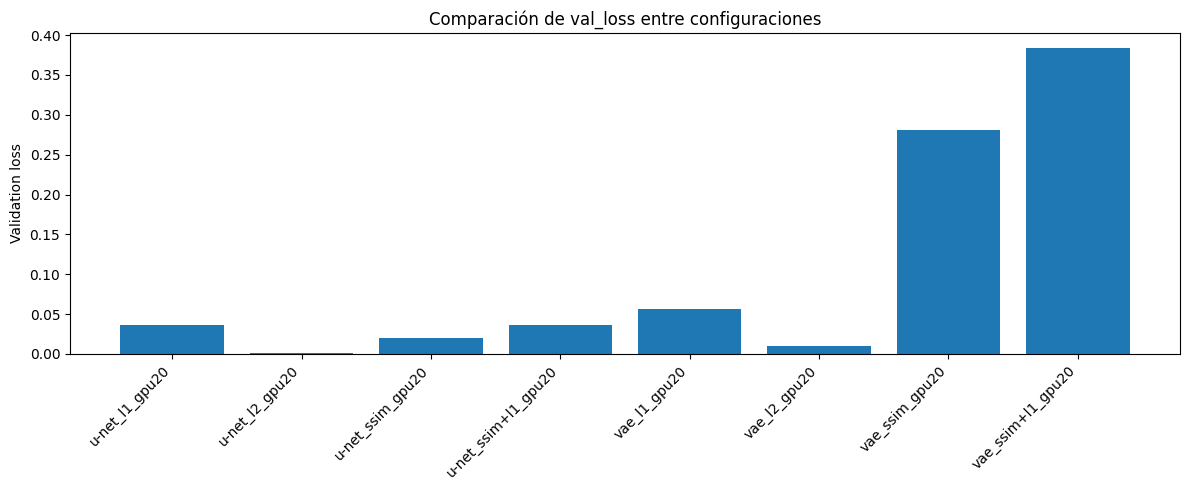

In [13]:
import matplotlib.pyplot as plt

df_plot = df_results.sort_values(["model", "loss_type"])

plt.figure(figsize=(12, 5))
plt.bar(df_plot["run"], df_plot["val/loss"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation loss")
plt.title("Comparación de val_loss entre configuraciones")
plt.tight_layout()
plt.show()

c:\Users\antho\Documents\GitHub\Tarea3-IA\.venv312\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


initial size  8
initial size  8
initial size  8
initial size  8


,run,model,loss,class_name,defect_type,is_anomaly,reconstruction_error
0,u-net_l1_gpu20,u-net,l1,cable,bent_wire,True,0.039801
1,u-net_l1_gpu20,u-net,l1,cable,bent_wire,True,0.038109
2,u-net_l1_gpu20,u-net,l1,cable,bent_wire,True,0.038483
3,u-net_l1_gpu20,u-net,l1,cable,bent_wire,True,0.040302
4,u-net_l1_gpu20,u-net,l1,cable,bent_wire,True,0.040432
...,...,...,...,...,...,...,...
4331,vae_ssim_gpu20,vae,ssim,transistor,misplaced,True,0.465543
4332,vae_ssim_gpu20,vae,ssim,transistor,misplaced,True,0.361050
4333,vae_ssim_gpu20,vae,ssim,transistor,misplaced,True,0.373117
4334,vae_ssim_gpu20,vae,ssim,transistor,misplaced,True,0.372701


<Figure size 1400x600 with 0 Axes>

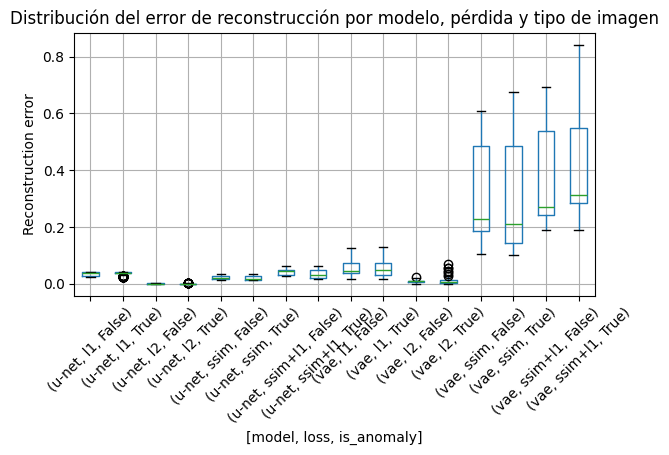

In [25]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import wandb
from IPython.display import display
from torchmetrics.functional import structural_similarity_index_measure as ssim

from data.datamodule import MVTecDataModule
from models.vae.model import VAEAutoEncoder

unet_module = importlib.import_module("models.u-net.model")
UNetAutoEncoder = unet_module.UNetAutoEncoder

ENTITY = "anthonyguevara2004-tecnologico-costa-rica"
PROJECT = "tarea-03-autoencoders"
TARGET_RUNS = {
    "vae_l1_gpu20",
    "vae_l2_gpu20",
    "vae_ssim_gpu20",
    "vae_ssim+l1_gpu20",
    "u-net_l1_gpu20",
    "u-net_l2_gpu20",
    "u-net_ssim_gpu20",
    "u-net_ssim+l1_gpu20",
}

project_root = Path.cwd()
datamodule = MVTecDataModule(
    checkpoint_path=str(project_root / "data" / "cache" / "mvtec_anomaly_detection.pt"),
    batch_size=32,
    num_workers=1,
)
datamodule.setup(stage="test")

class_names = {idx: name for name, idx in datamodule.class_to_idx.items()}
defect_names = {
    class_name: {code: defect_name for defect_name, code in defect_map.items()}
    for class_name, defect_map in datamodule.defect_mappings.items()
}

api = wandb.Api()
all_runs = {run.name: run for run in api.runs(f"{ENTITY}/{PROJECT}")}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_config_value(config, dotted_key, default=None):
    config_dict = config.as_dict() if hasattr(config, "as_dict") else dict(config)

    current = config_dict
    for part in dotted_key.split("."):
        if isinstance(current, dict) and part in current:
            current = current[part]
        else:
            return config_dict.get(dotted_key, default)

    return current


def resolve_checkpoint_path(run_id):
    checkpoint_dir = project_root / "tarea-03-autoencoders" / run_id / "checkpoints"
    checkpoint_files = sorted(
        checkpoint_dir.glob("*.ckpt"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint found for run {run_id}")
    return checkpoint_files[0]


def build_model(run):
    model_name = run.name.split("_", 1)[0]
    checkpoint_path = resolve_checkpoint_path(run.id)

    if model_name == "vae":
        model = VAEAutoEncoder.load_from_checkpoint(str(checkpoint_path), map_location="cpu")
    elif model_name == "u-net":
        model = UNetAutoEncoder.load_from_checkpoint(str(checkpoint_path), map_location="cpu")
    else:
        raise ValueError(f"Unsupported model name for run {run.name}: {model_name}")

    model.eval()
    model.to(device)
    return model, checkpoint_path


def reconstruction_error_per_sample(model, x, x_hat):
    loss_type = str(model.hparams.loss_type).lower()

    if loss_type == "l1":
        return torch.mean(torch.abs(x_hat - x), dim=(1, 2, 3))

    if loss_type in {"l2", "mse"}:
        return torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))

    if loss_type == "ssim":
        return torch.stack([
            1.0 - ssim(x_hat[i : i + 1], x[i : i + 1], data_range=1.0)
            for i in range(x.size(0))
        ])

    if loss_type == "ssim+l1":
        ssim_errors = torch.stack([
            1.0 - ssim(x_hat[i : i + 1], x[i : i + 1], data_range=1.0)
            for i in range(x.size(0))
        ])
        l1_errors = torch.mean(torch.abs(x_hat - x), dim=(1, 2, 3))
        return ssim_errors + l1_errors

    raise ValueError(f"Unsupported loss type: {loss_type}")


rows = []
with torch.no_grad():
    for run_name in sorted(TARGET_RUNS):
        run = all_runs[run_name]
        model, checkpoint_path = build_model(run)
        model_name = run.name.split("_", 1)[0]
        loss_name = str(get_config_value(run.config, "model.loss_type") or run.config.get("loss_type") or model.hparams.loss_type).lower()

        for batch in datamodule.test_dataloader():
            x, y = batch
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            x_hat = outputs[0] if isinstance(outputs, tuple) else outputs
            errors = reconstruction_error_per_sample(model, x, x_hat).detach().cpu()

            class_indices = y[:, 0].detach().cpu().tolist()
            defect_indices = y[:, 1].detach().cpu().tolist()

            for idx, class_idx in enumerate(class_indices):
                class_name = class_names[int(class_idx)]
                defect_index = int(defect_indices[idx])
                defect_type = defect_names[class_name][defect_index]
                rows.append(
                    {
                        "run": run.name,
                        "model": model_name,
                        "loss": loss_name,
                        "class_name": class_name,
                        "defect_type": defect_type,
                        "is_anomaly": defect_index != 0,
                        "reconstruction_error": float(errors[idx].item()),
                    }
                )


df_errors = pd.DataFrame(rows)
df_errors = df_errors.sort_values(["run", "class_name", "defect_type"]).reset_index(drop=True)
display(df_errors)

plt.figure(figsize=(14, 6))
df_errors.boxplot(
    column="reconstruction_error",
    by=["model", "loss", "is_anomaly"],
    rot=45,
)
plt.title("Distribución del error de reconstrucción por modelo, pérdida y tipo de imagen")
plt.suptitle("")
plt.ylabel("Reconstruction error")
plt.tight_layout()
plt.show()

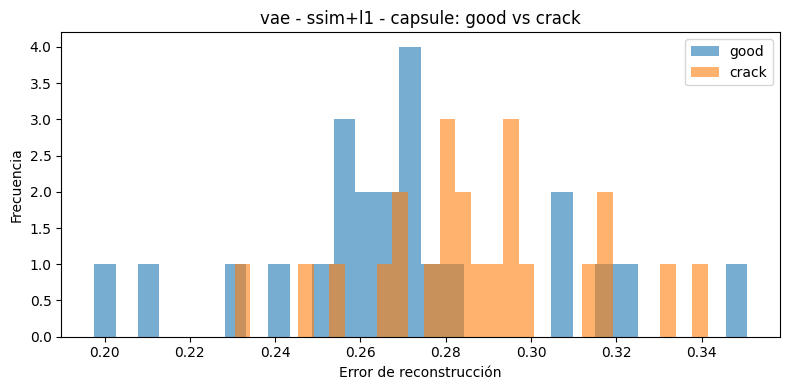

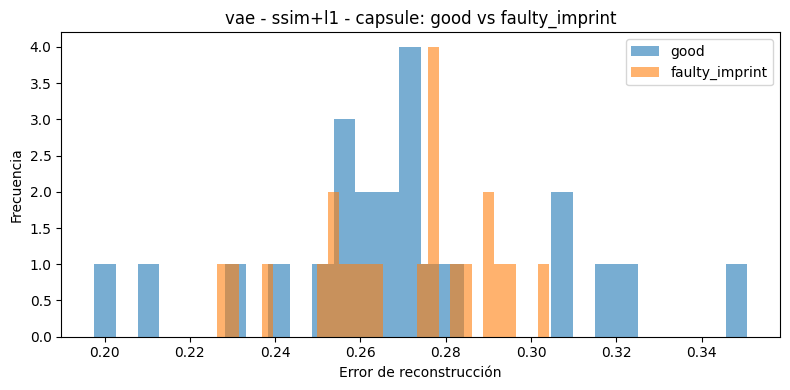

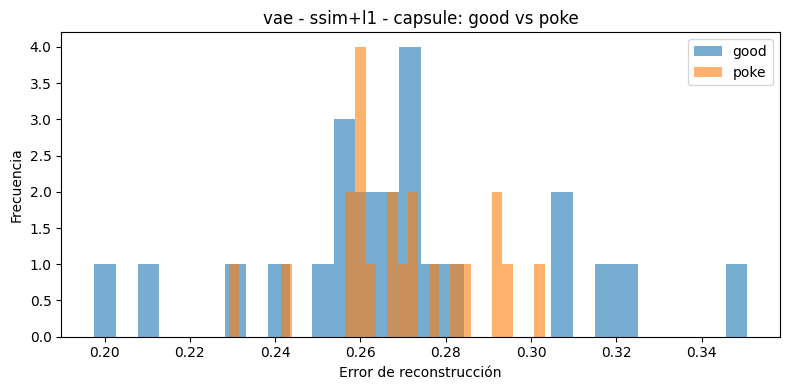

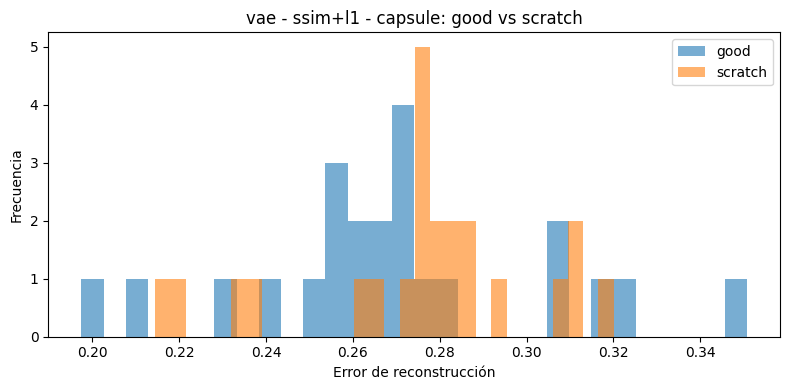

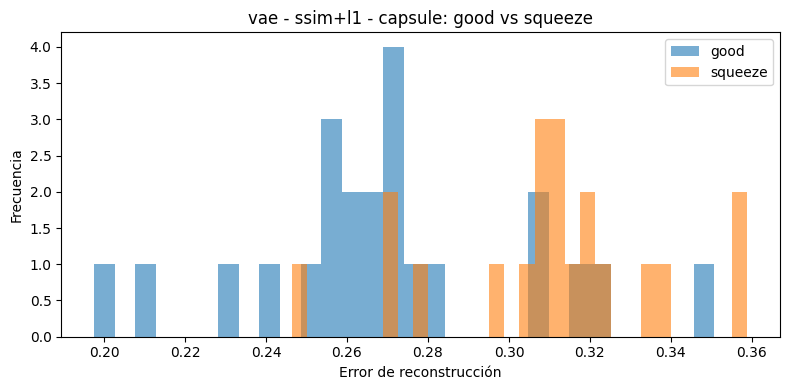

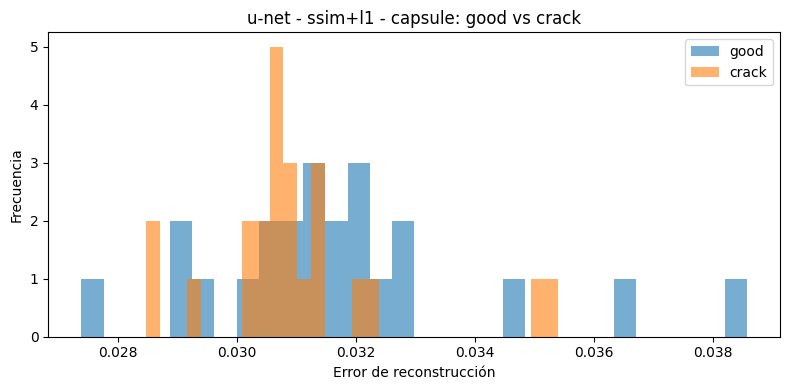

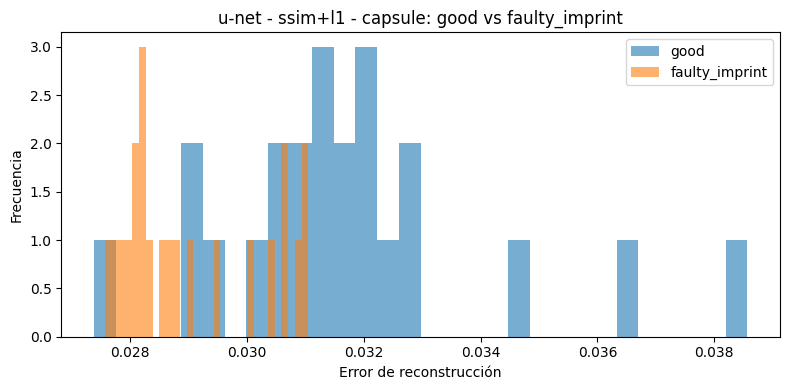

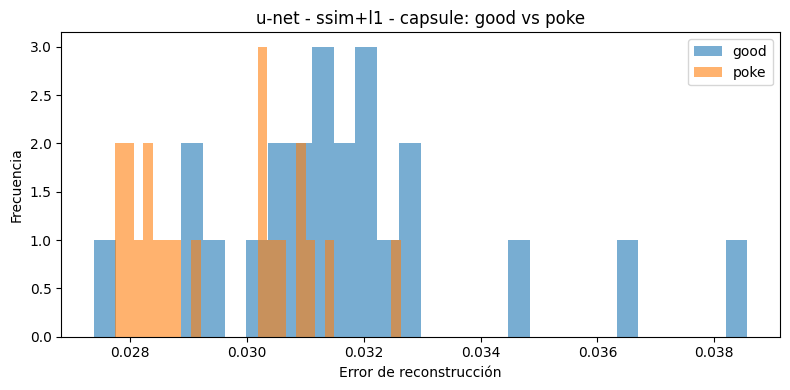

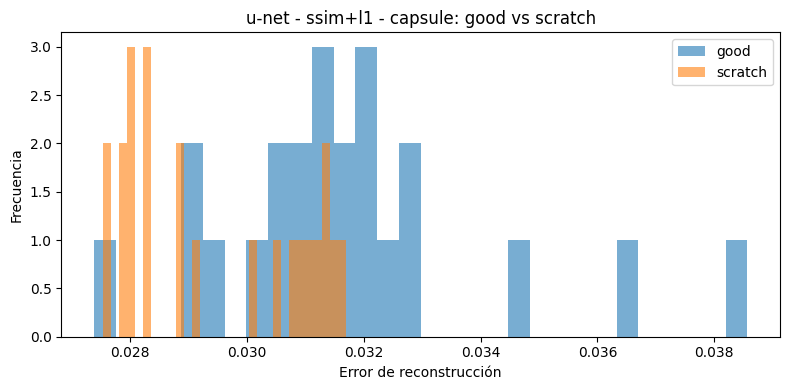

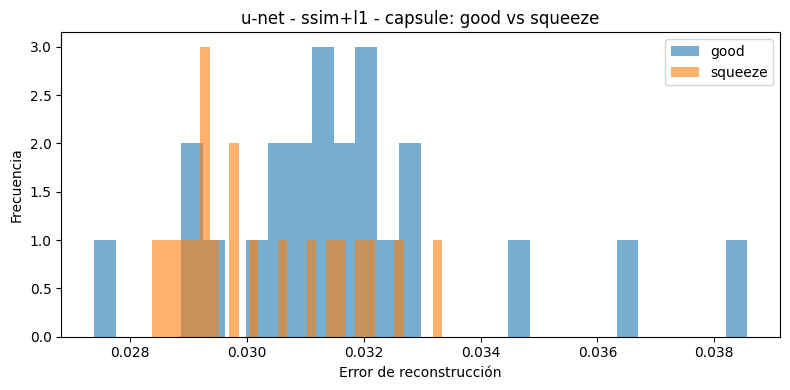

In [20]:
import matplotlib.pyplot as plt

def plot_hist_by_defect(df_errors, model_name, loss_name, object_class):
    subset = df_errors[
        (df_errors["model"] == model_name) &
        (df_errors["loss"] == loss_name) &
        (df_errors["class_name"] == object_class)
    ]

    good_errors = subset[subset["defect_type"] == "good"]["reconstruction_error"]

    defect_types = [
        d for d in subset["defect_type"].unique()
        if d != "good"
    ]

    for defect in defect_types:
        defect_errors = subset[subset["defect_type"] == defect]["reconstruction_error"]

        plt.figure(figsize=(8, 4))
        plt.hist(good_errors, bins=30, alpha=0.6, label="good")
        plt.hist(defect_errors, bins=30, alpha=0.6, label=defect)
        plt.title(f"{model_name} - {loss_name} - {object_class}: good vs {defect}")
        plt.xlabel("Error de reconstrucción")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_hist_by_defect(df_errors, "vae", "ssim+l1", "capsule")
plot_hist_by_defect(df_errors, "u-net", "ssim+l1", "capsule")

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

summary = (
    df_errors
    .groupby(["run", "model", "loss", "is_anomaly"])["reconstruction_error"]
    .mean()
    .reset_index()
)

pivot = summary.pivot_table(
    index=["run", "model", "loss"],
    columns="is_anomaly",
    values="reconstruction_error"
).reset_index()

pivot = pivot.rename(columns={0: "mae_good", 1: "mae_anomaly"})
pivot["separation"] = pivot["mae_anomaly"] - pivot["mae_good"]

pivot.sort_values("separation", ascending=False)

is_anomaly,run,model,loss,mae_good,mae_anomaly,separation
6,vae_ssim+l1_gpu20,vae,ssim+l1,0.358683,0.386753,0.028070
0,u-net_l1_gpu20,u-net,l1,0.034726,0.037510,0.002784
1,u-net_l2_gpu20,u-net,l2,0.000740,0.000717,-0.000024
5,vae_l2_gpu20,vae,l2,0.008385,0.007820,-0.000566
4,vae_l1_gpu20,vae,l1,0.054595,0.053770,-0.000825
3,u-net_ssim_gpu20,u-net,ssim,0.021622,0.019182,-0.002440
2,u-net_ssim+l1_gpu20,u-net,ssim+l1,0.042125,0.034468,-0.007657
7,vae_ssim_gpu20,vae,ssim,0.298691,0.279057,-0.019634


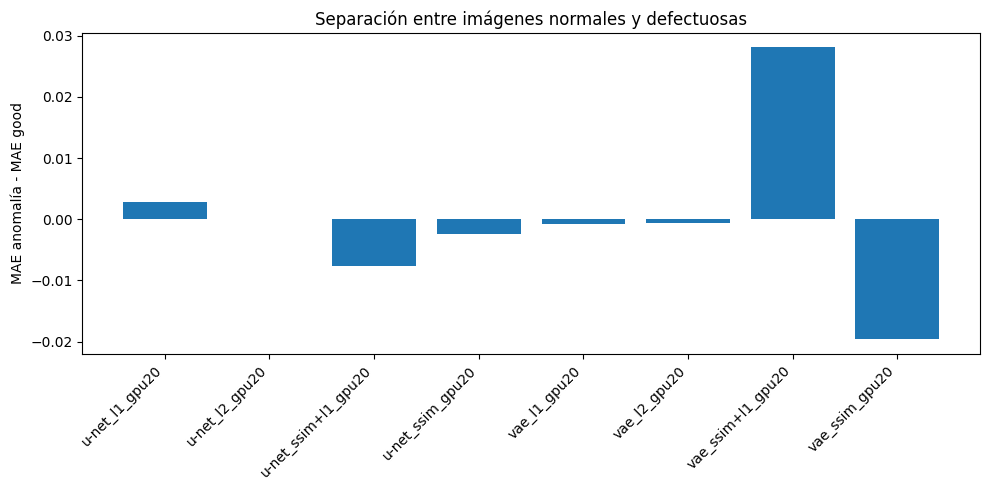

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(pivot["run"], pivot["separation"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE anomalía - MAE good")
plt.title("Separación entre imágenes normales y defectuosas")
plt.tight_layout()
plt.show()

In [23]:
ranking = pivot.sort_values("separation", ascending=False)

ranking[[
    "run",
    "model",
    "loss",
    "mae_good",
    "mae_anomaly",
    "separation"
]]

is_anomaly,run,model,loss,mae_good,mae_anomaly,separation
6,vae_ssim+l1_gpu20,vae,ssim+l1,0.358683,0.386753,0.028070
0,u-net_l1_gpu20,u-net,l1,0.034726,0.037510,0.002784
1,u-net_l2_gpu20,u-net,l2,0.000740,0.000717,-0.000024
5,vae_l2_gpu20,vae,l2,0.008385,0.007820,-0.000566
4,vae_l1_gpu20,vae,l1,0.054595,0.053770,-0.000825
3,u-net_ssim_gpu20,u-net,ssim,0.021622,0.019182,-0.002440
2,u-net_ssim+l1_gpu20,u-net,ssim+l1,0.042125,0.034468,-0.007657
7,vae_ssim_gpu20,vae,ssim,0.298691,0.279057,-0.019634


-- Clase: cable


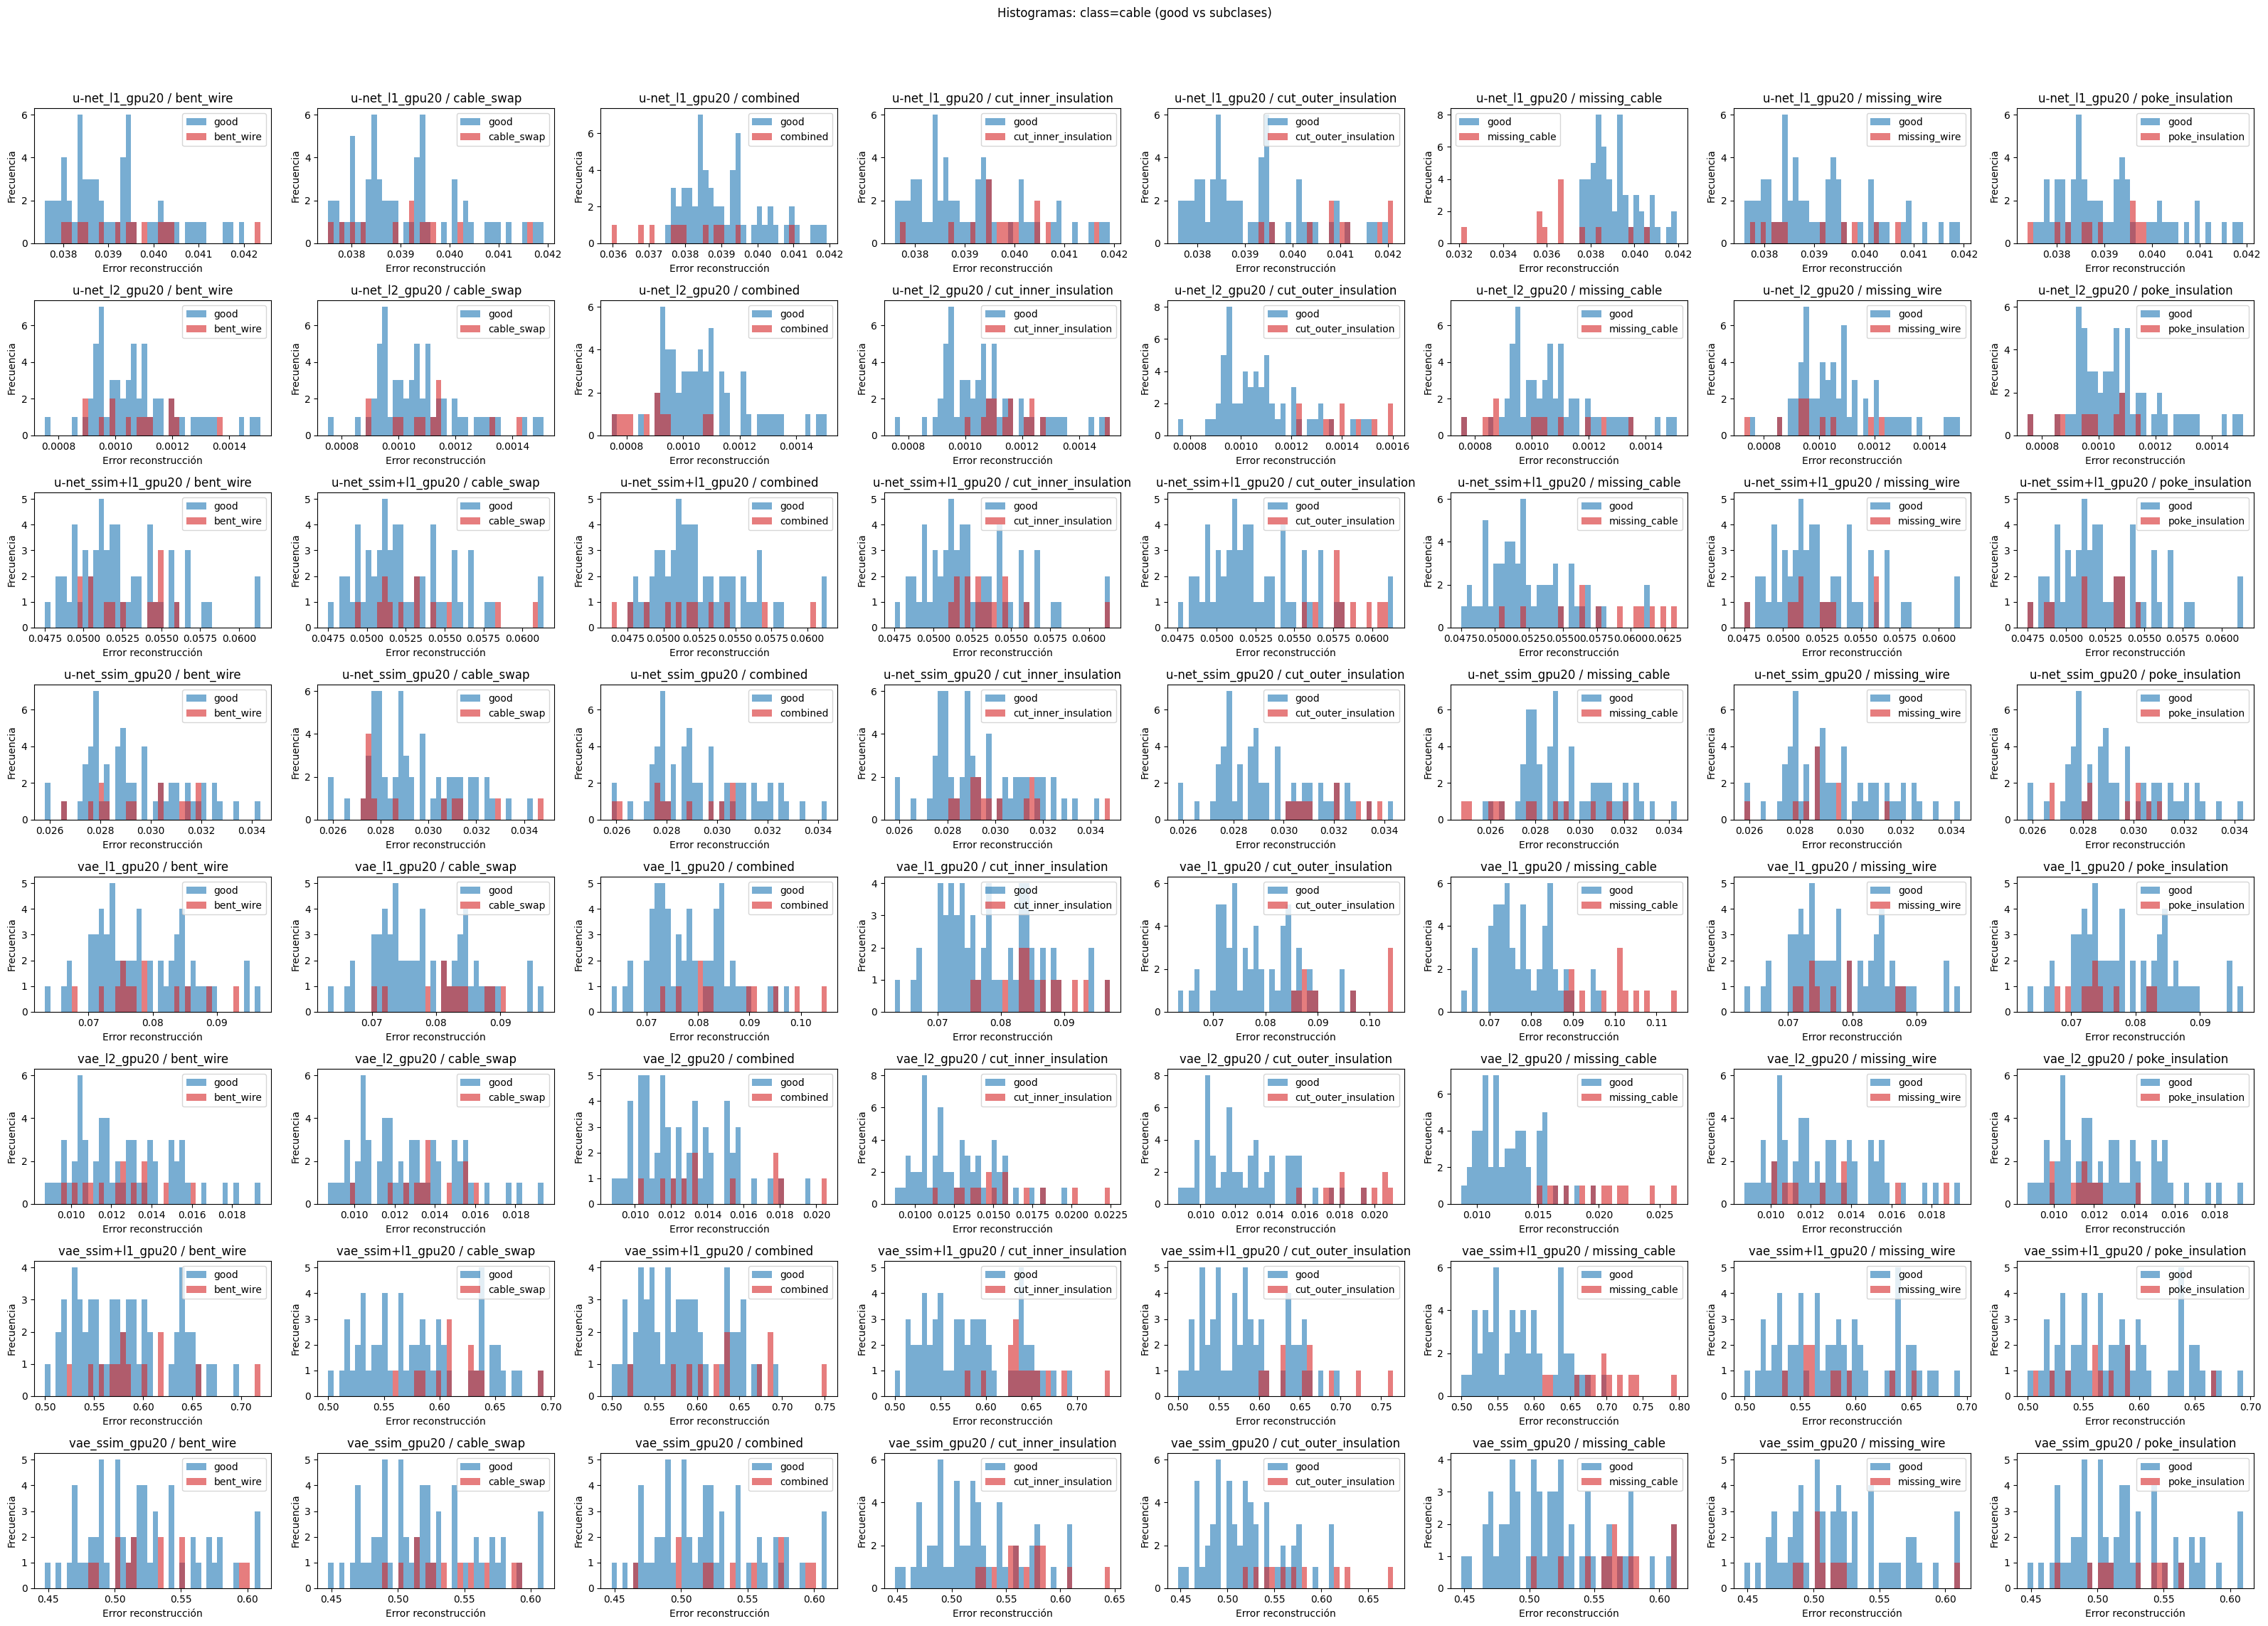

-- Clase: capsule


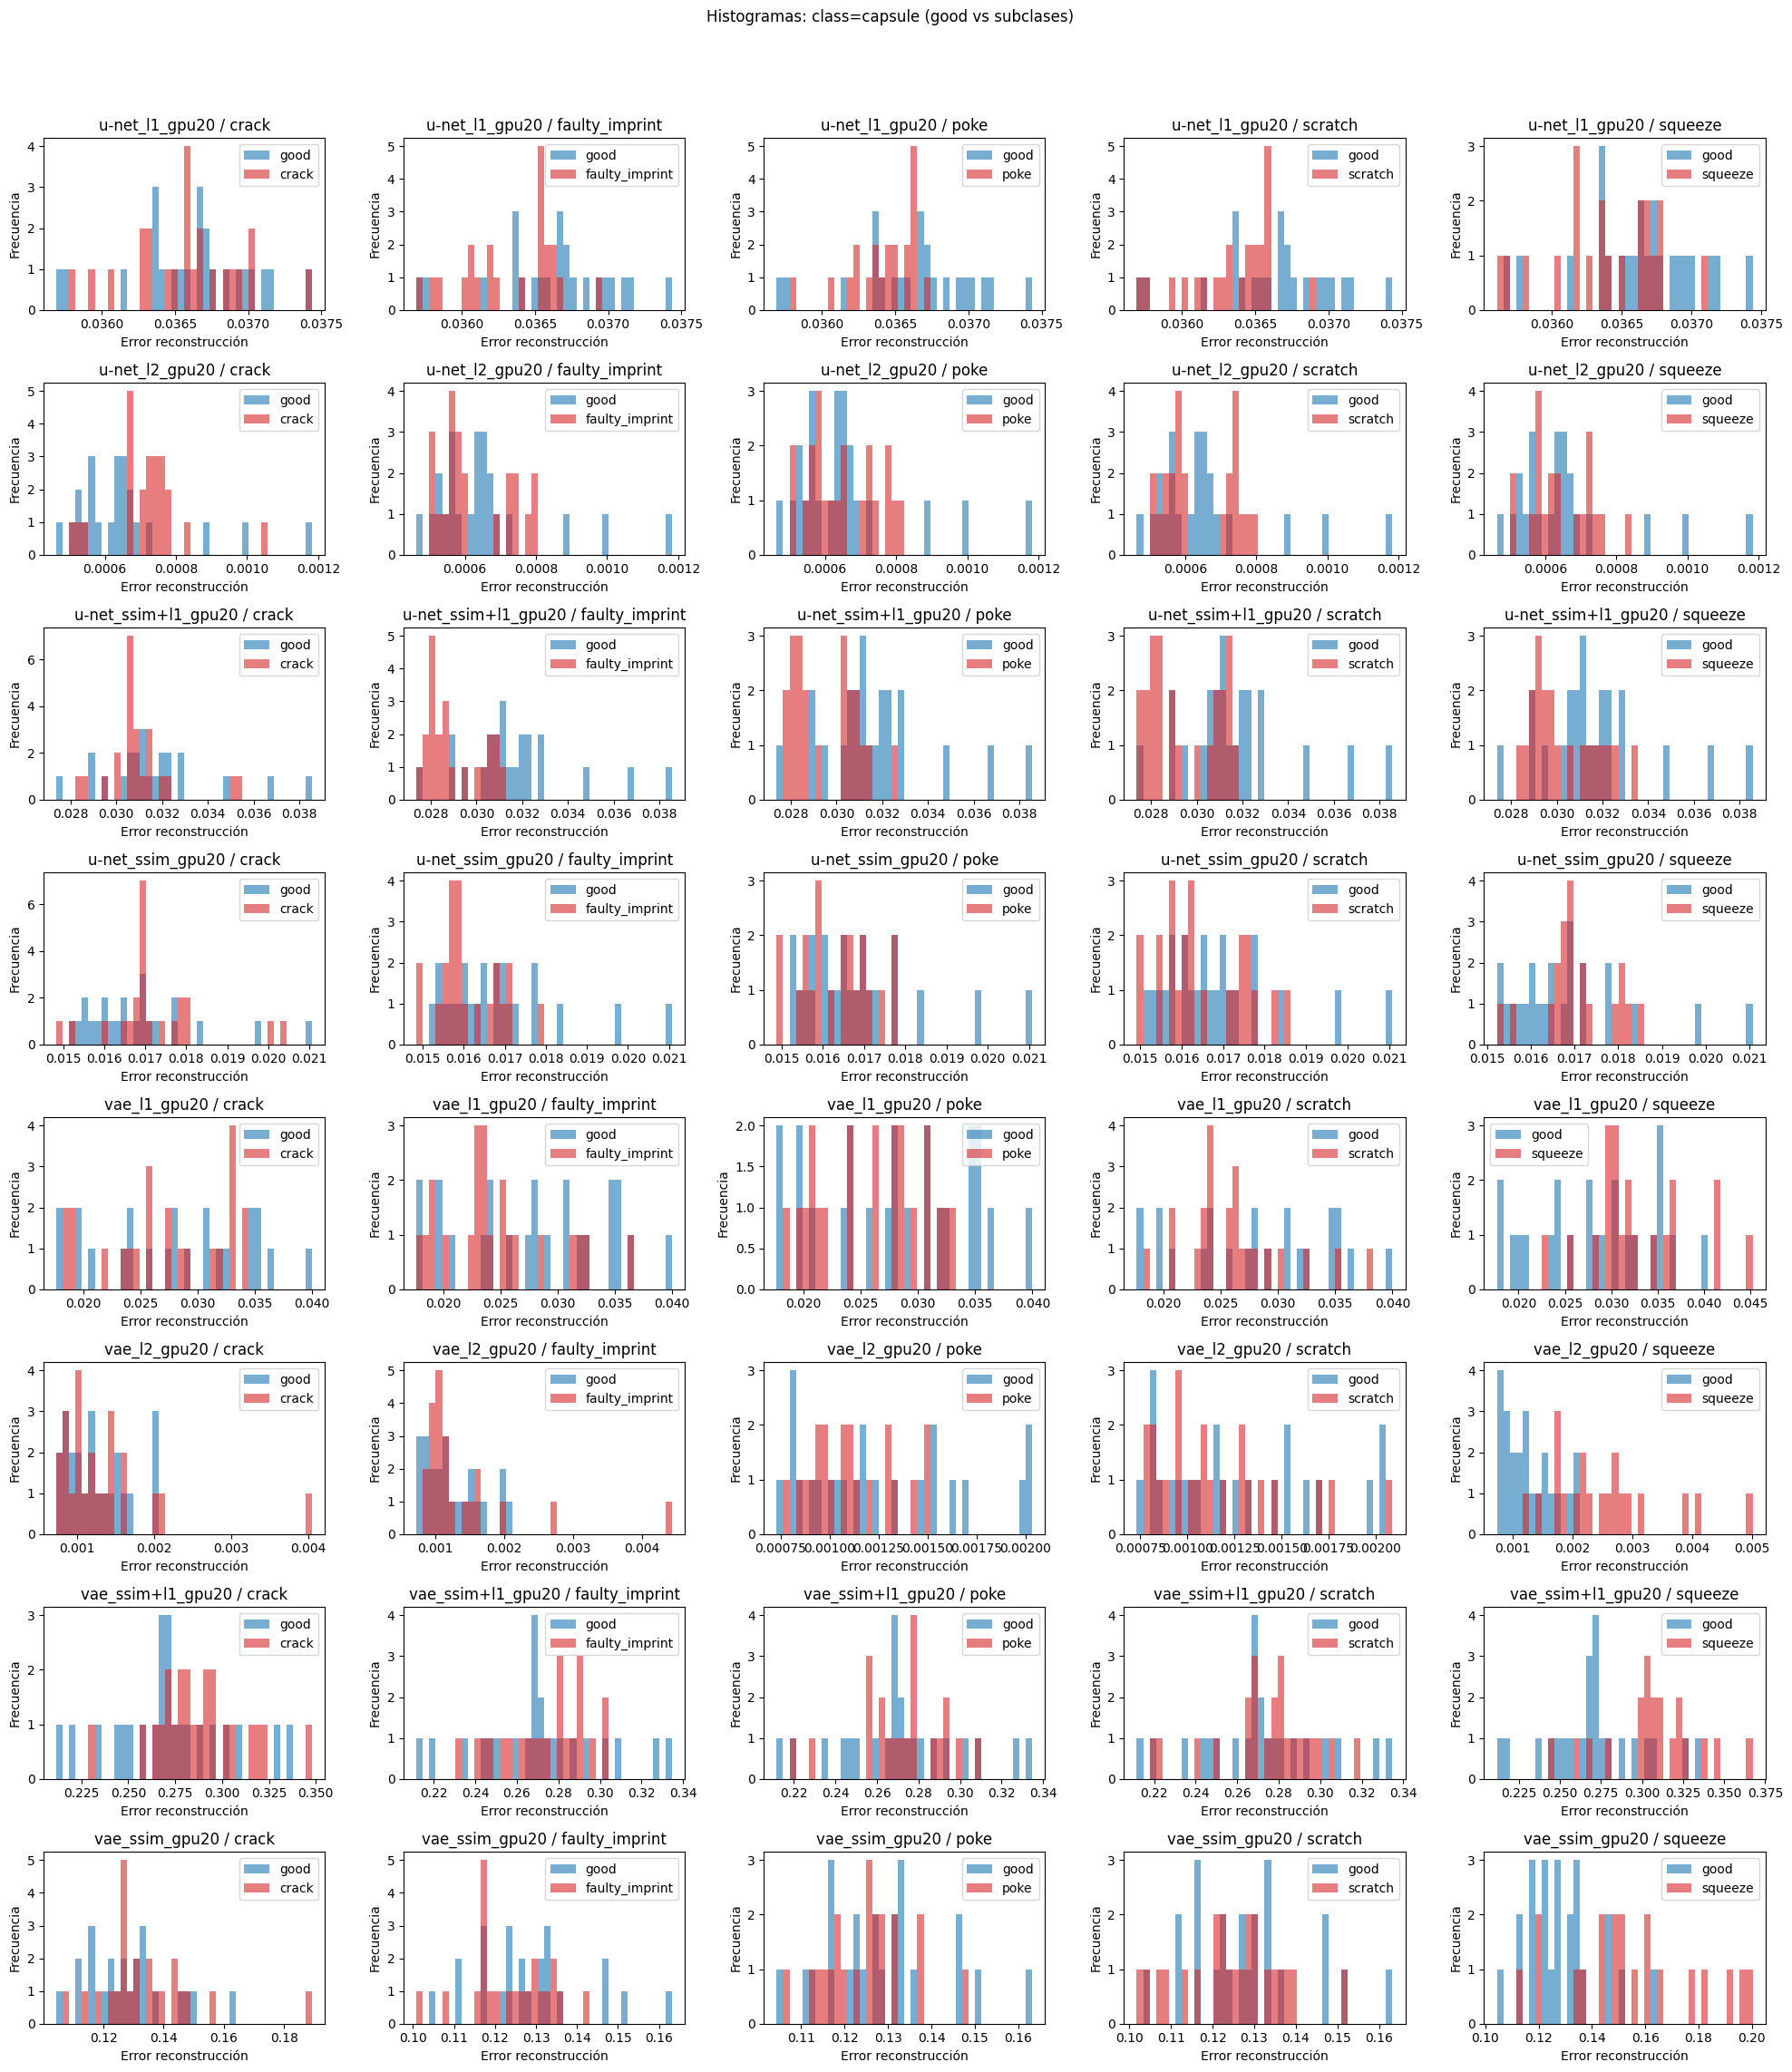

-- Clase: screw


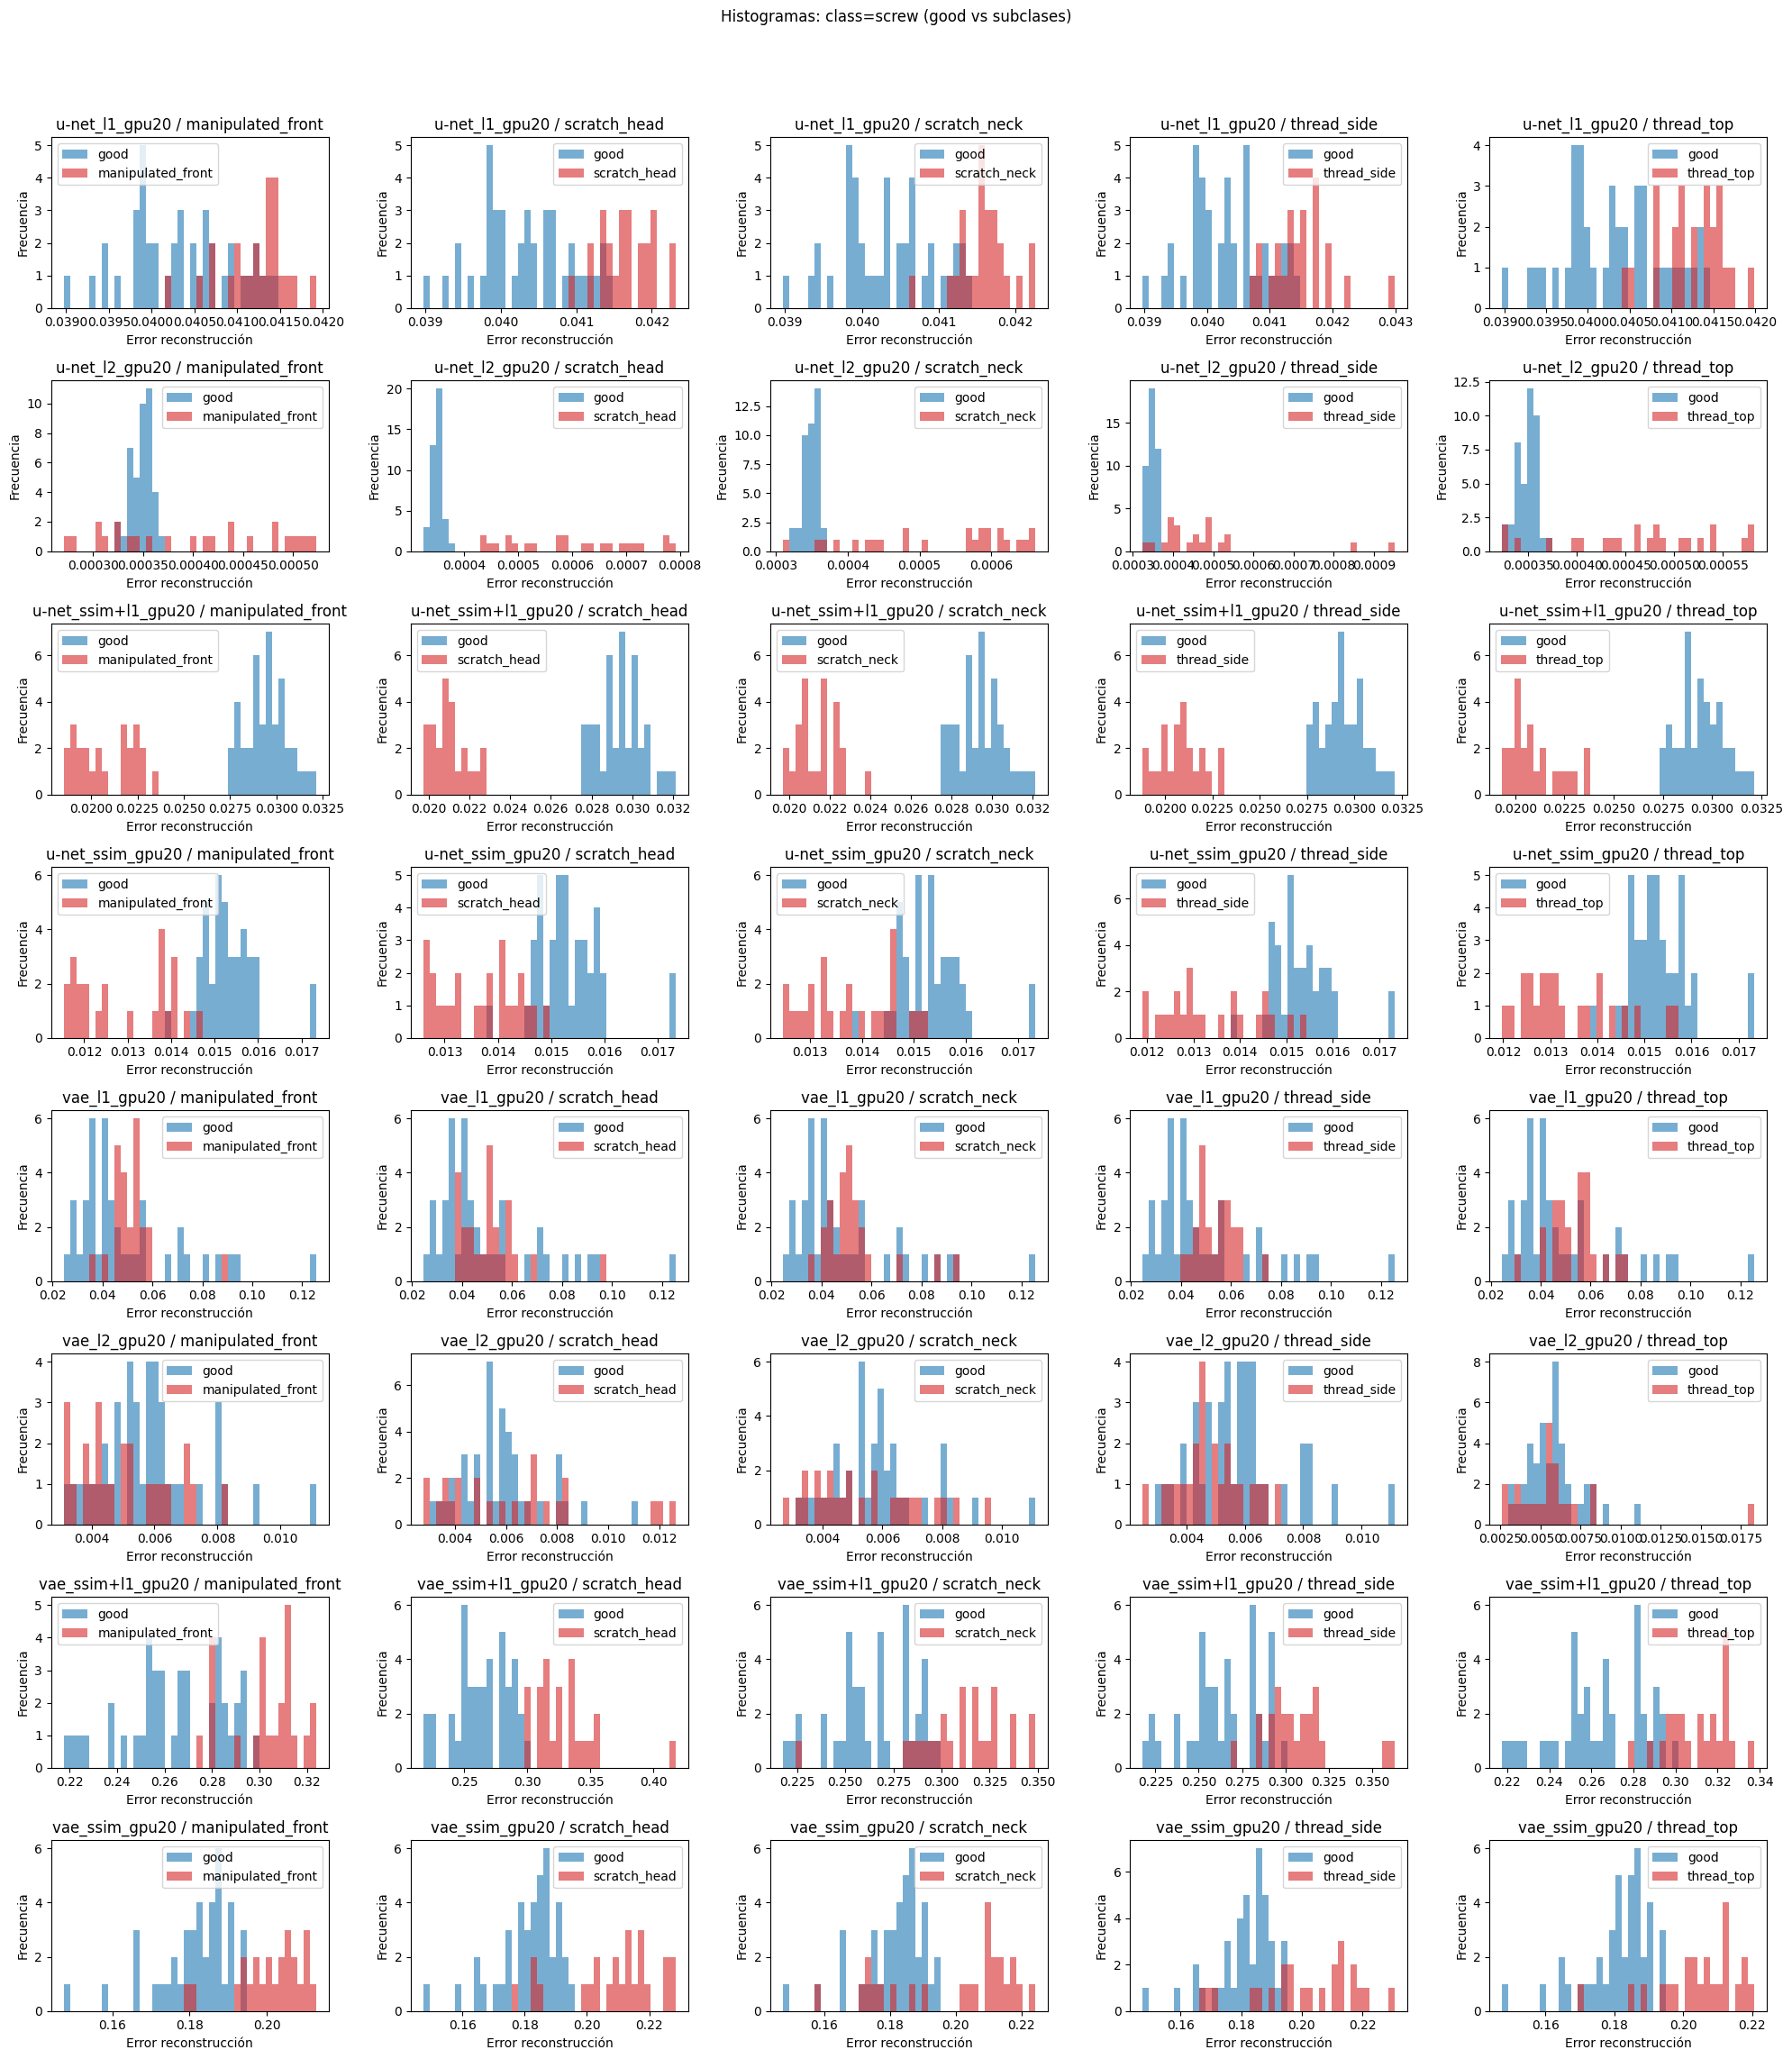

-- Clase: transistor


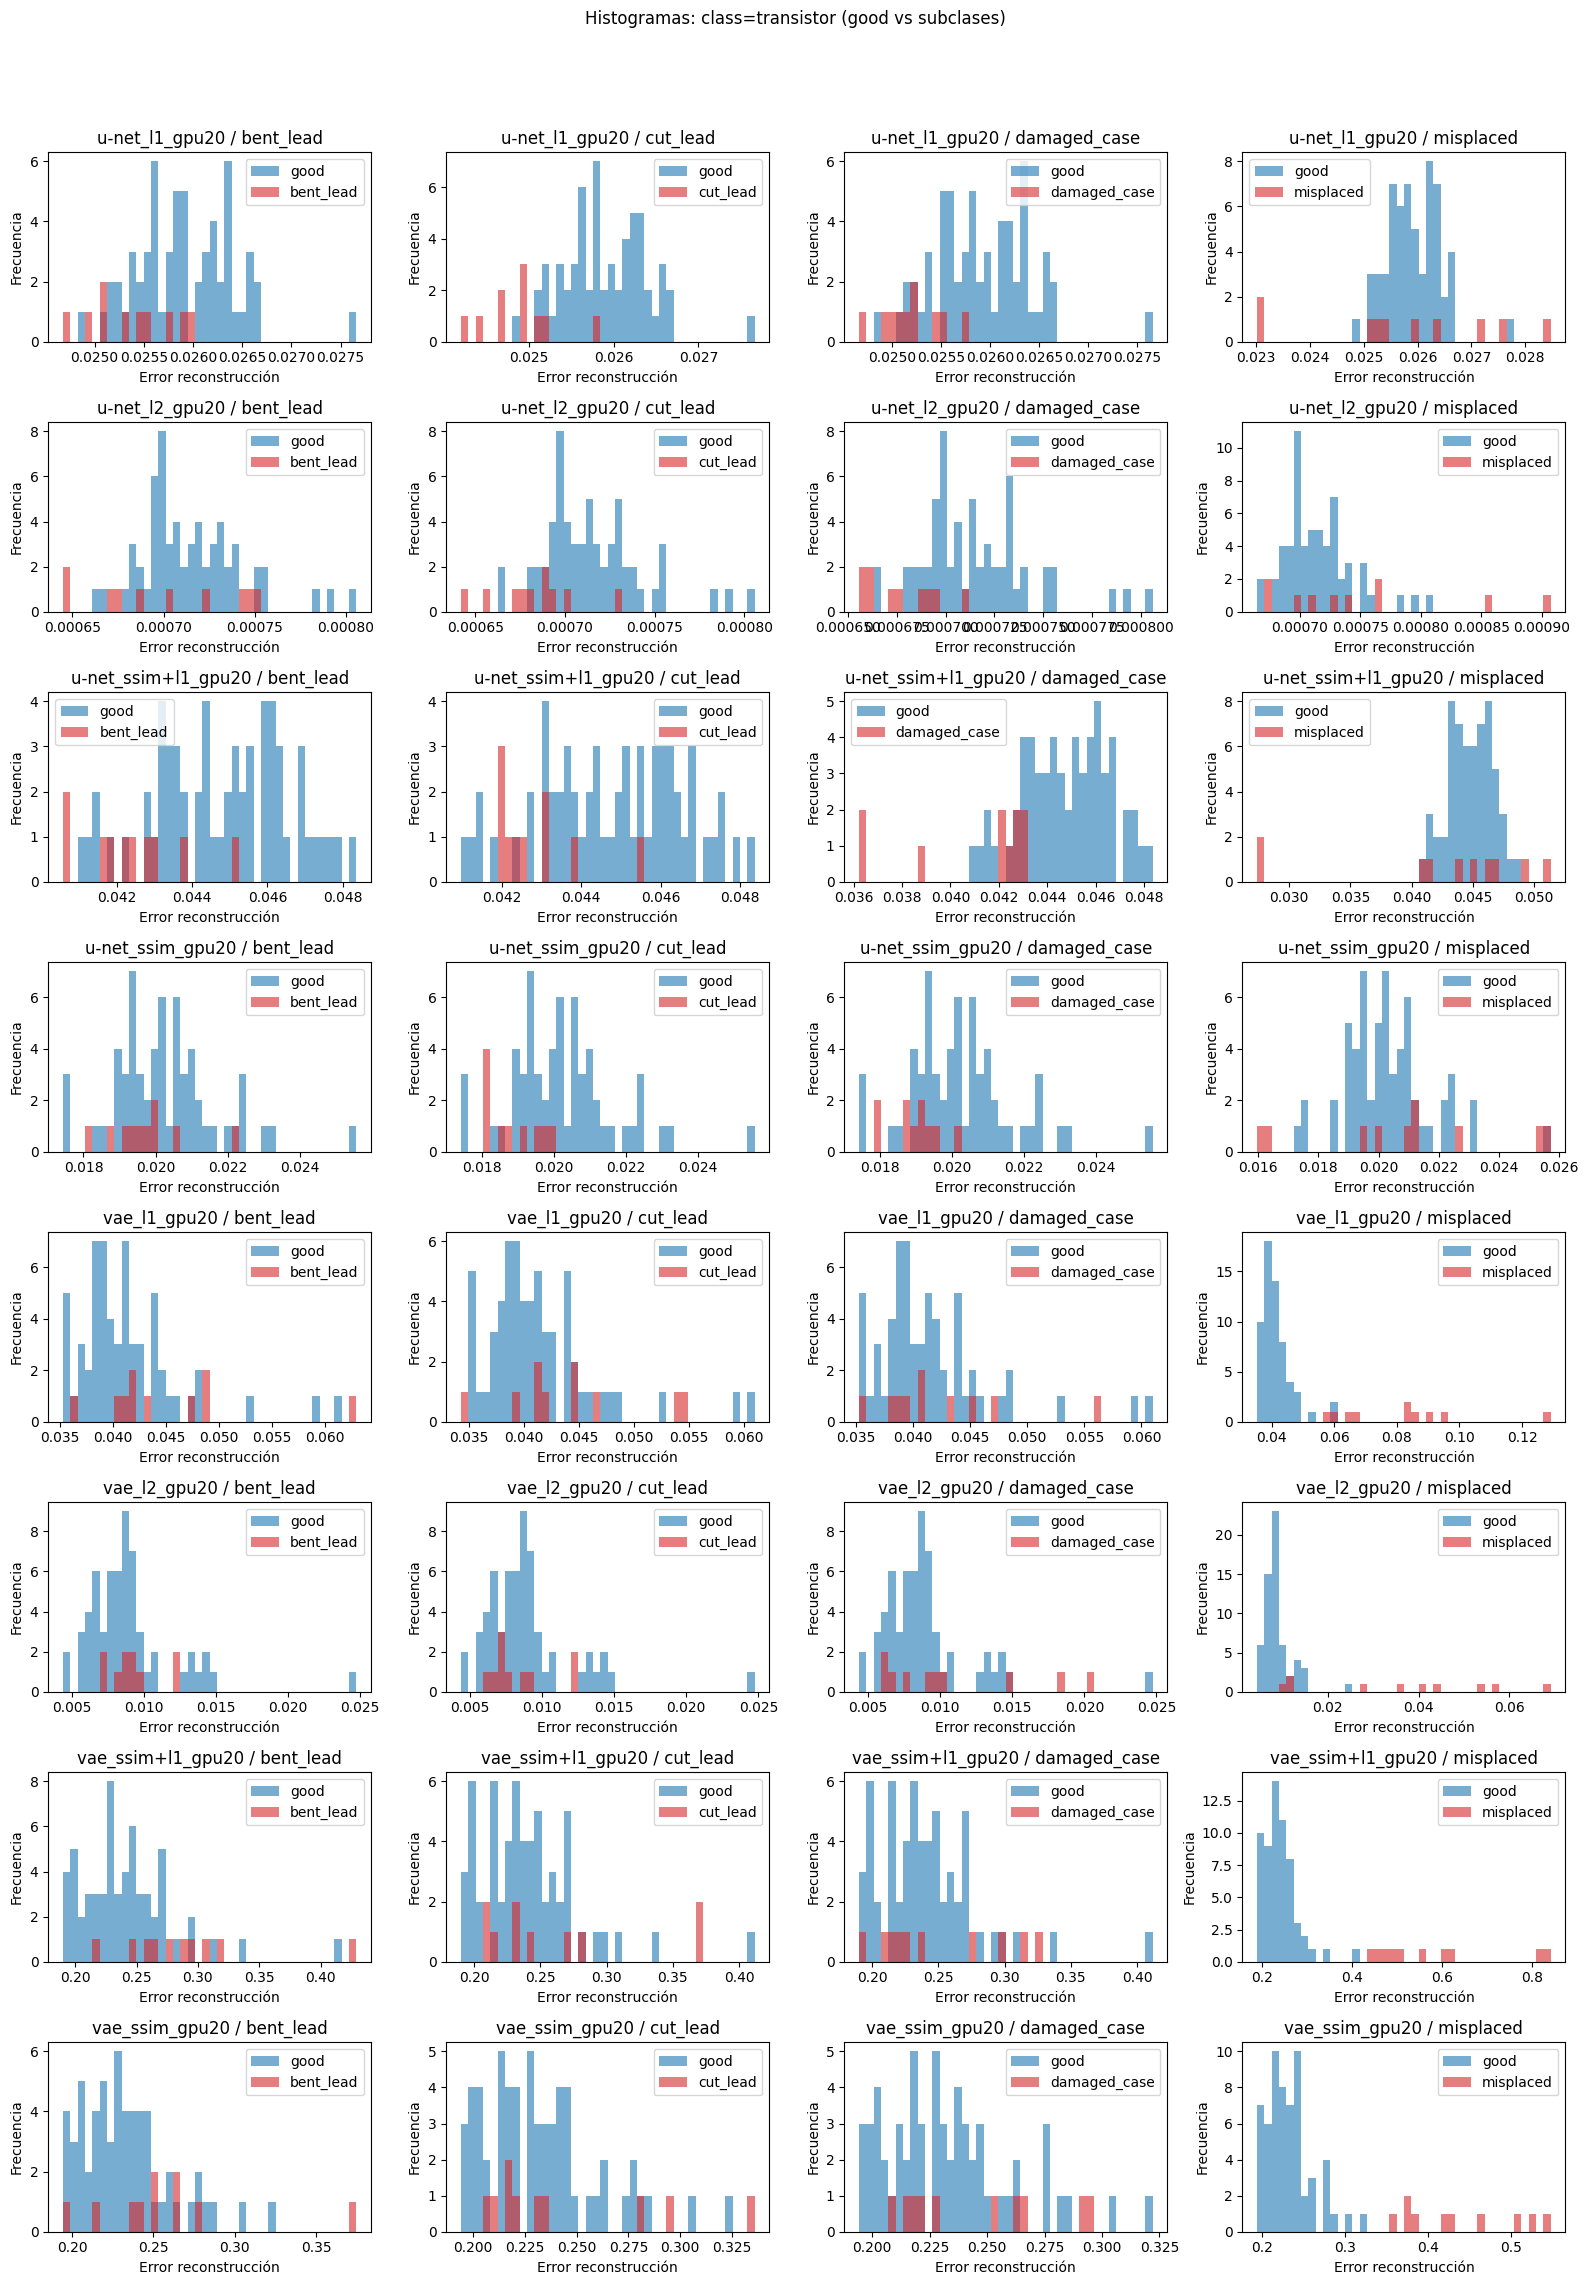

,run,auc,ap
6,vae_ssim+l1_gpu20,0.651068,0.754582
0,u-net_l1_gpu20,0.608516,0.788095
4,vae_l1_gpu20,0.501114,0.694253
1,u-net_l2_gpu20,0.466331,0.647499
7,vae_ssim_gpu20,0.445314,0.664465
5,vae_l2_gpu20,0.407784,0.668570
3,u-net_ssim_gpu20,0.349283,0.605094
2,u-net_ssim+l1_gpu20,0.318559,0.614529


,run,class_name,auc
2,u-net_l1_gpu20,screw,0.933798
0,u-net_l1_gpu20,cable,0.514243
1,u-net_l1_gpu20,capsule,0.323494
3,u-net_l1_gpu20,transistor,0.211667
6,u-net_l2_gpu20,screw,0.880713
5,u-net_l2_gpu20,capsule,0.566414
4,u-net_l2_gpu20,cable,0.504123
7,u-net_l2_gpu20,transistor,0.323333
8,u-net_ssim+l1_gpu20,cable,0.623501
9,u-net_ssim+l1_gpu20,capsule,0.244515


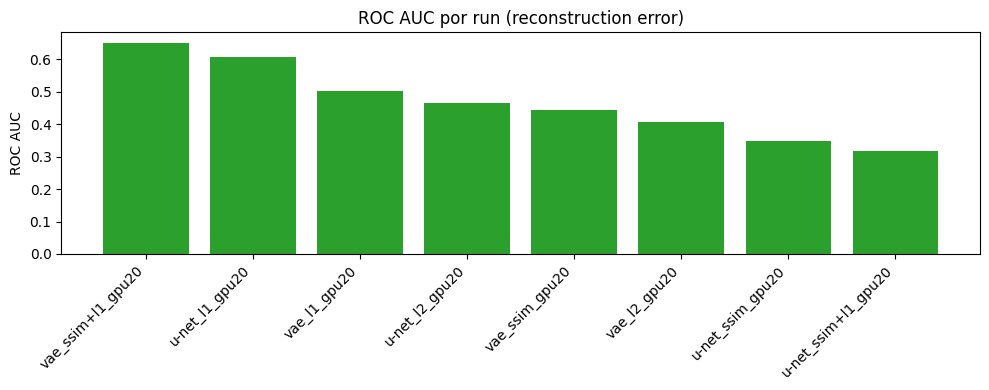

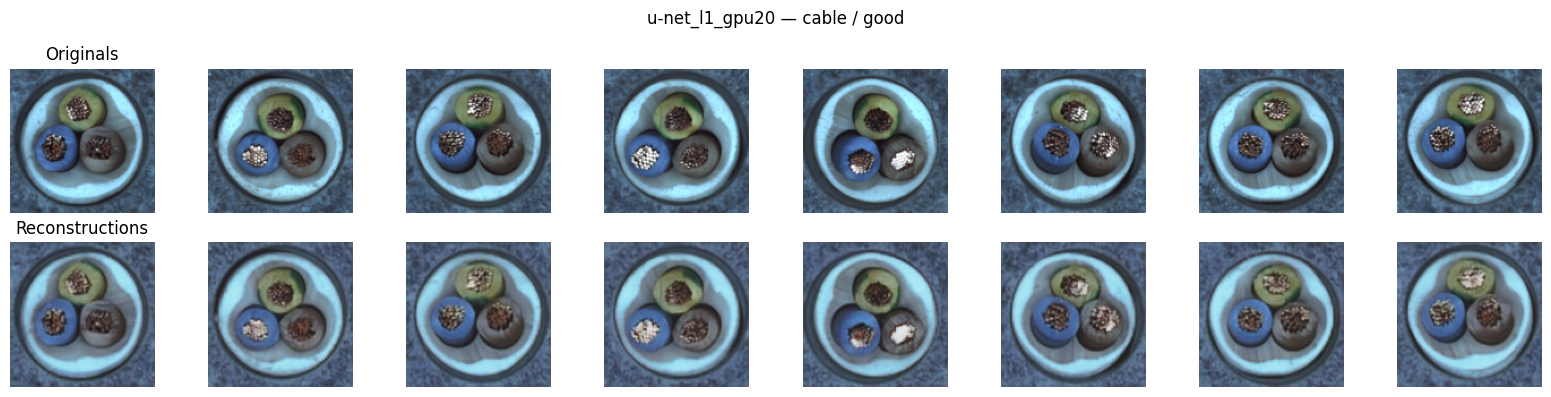

In [34]:
# Integración: histogramas por subclase, AUC/PR y grids de reconstrucción
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Comprueba que df_errors existe
assert 'df_errors' in globals(), "Ejecute la celda que genera `df_errors` primero."

runs = sorted(df_errors['run'].unique())
classes = sorted(df_errors['class_name'].unique())

# 1) Histogramas: por clase, filas=runs, columnas=subclases (excluyendo 'good')
def plot_histograms_by_class(df, class_name, runs=None):
    subset_class = df[df['class_name'] == class_name]
    defect_types = [d for d in sorted(subset_class['defect_type'].unique()) if d != 'good']
    if len(defect_types) == 0:
        print(f"No defect types for class {class_name}")
        return

    uses = runs or sorted(subset_class['run'].unique())
    n_rows = len(uses)
    n_cols = len(defect_types)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

    for i, run in enumerate(uses):
        for j, defect in enumerate(defect_types):
            ax = axes[i][j]
            good_errors = subset_class[(subset_class['run'] == run) & (subset_class['defect_type'] == 'good')]['reconstruction_error']
            defect_errors = subset_class[(subset_class['run'] == run) & (subset_class['defect_type'] == defect)]['reconstruction_error']

            if len(good_errors) == 0 and len(defect_errors) == 0:
                ax.text(0.5, 0.5, 'sin datos', ha='center')
                ax.set_title(f"{run} / {defect}")
                continue

            bins = np.histogram(np.hstack([good_errors, defect_errors]), bins=40)[1] if len(good_errors) + len(defect_errors) > 0 else 30
            if len(good_errors) > 0:
                ax.hist(good_errors, bins=bins, alpha=0.6, label='good', color='C0')
            if len(defect_errors) > 0:
                ax.hist(defect_errors, bins=bins, alpha=0.6, label=defect, color='C3')

            ax.set_title(f"{run} / {defect}")
            ax.set_xlabel('Error reconstrucción')
            ax.set_ylabel('Frecuencia')
            ax.legend()

    fig.suptitle(f"Histogramas: class={class_name} (good vs subclases)")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 2) AUC / PR por run y por clase

def compute_auc_summary(df):
    rows = []
    for run in sorted(df['run'].unique()):
        sub = df[df['run'] == run]
        y_true = sub['is_anomaly'].astype(int).values
        y_score = sub['reconstruction_error'].values
        try:
            auc = roc_auc_score(y_true, y_score)
        except Exception:
            auc = np.nan
        try:
            ap = average_precision_score(y_true, y_score)
        except Exception:
            ap = np.nan
        rows.append({'run': run, 'auc': auc, 'ap': ap})

    auc_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
    display(auc_df)

    # Per class
    rows_c = []
    for run in sorted(df['run'].unique()):
        for cls in sorted(df['class_name'].unique()):
            sub = df[(df['run'] == run) & (df['class_name'] == cls)]
            if len(sub) < 10:
                continue
            y_true = sub['is_anomaly'].astype(int).values
            y_score = sub['reconstruction_error'].values
            try:
                auc = roc_auc_score(y_true, y_score)
            except Exception:
                auc = np.nan
            rows_c.append({'run': run, 'class_name': cls, 'auc': auc})

    auc_cls_df = pd.DataFrame(rows_c).dropna().sort_values(['run', 'auc'], ascending=[True, False])
    display(auc_cls_df)

    # Bar plot overall AUC
    plt.figure(figsize=(10, 4))
    plt.bar(auc_df['run'], auc_df['auc'], color='C2')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('ROC AUC')
    plt.title('ROC AUC por run (reconstruction error)')
    plt.tight_layout()
    plt.show()

# 3) Grids de reconstrucción: toma n ejemplos de la clase/defecto y muestra originales vs reconstrucciones

def show_reconstructions(run_name, class_name, defect_type, n=8):
    if run_name not in all_runs:
        print(f"Run {run_name} not found in `all_runs`")
        return
    run = all_runs[run_name]
    model_obj, _ = build_model(run)
    model_obj.eval()

    imgs = []
    recs = []
    found = 0
    with torch.no_grad():
        for batch in datamodule.test_dataloader():
            x, y = batch
            mask = (y[:, 0] == list(class_names.keys())[list(class_names.values()).index(class_name)]) if isinstance(class_names, dict) else (y[:,0]==class_name)
            # y[:,1] matches defect code
            # find defect code value
            dm = datamodule.defect_mappings[class_name]
            defect_code = dm.get(defect_type, None)
            if defect_code is None:
                continue
            sel = (y[:, 0] == list(class_names.keys())[list(class_names.values()).index(class_name)]) & (y[:, 1] == defect_code)
            if sel.any():
                idxs = torch.where(sel)[0]
                take = min(len(idxs), n - found)
                chosen = idxs[:take]
                x_sel = x[chosen].to(device)
                out = model_obj(x_sel)
                x_hat = out[0] if isinstance(out, tuple) else out
                imgs.append(x_sel.cpu())
                recs.append(x_hat.cpu())
                found += take
            if found >= n:
                break

    if found == 0:
        print(f"No samples found for {run_name} / {class_name} / {defect_type}")
        return

    imgs = torch.cat(imgs, dim=0)[:n]
    recs = torch.cat(recs, dim=0)[:n]

    # Plot grid: two rows (originals, reconstructions)
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for i in range(n):
        ax = axes[0, i]
        img = imgs[i].permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.axis('off')
        if i == 0:
            ax.set_title('Originals')

        ax2 = axes[1, i]
        rec = recs[i].permute(1, 2, 0).numpy()
        ax2.imshow(np.clip(rec, 0, 1))
        ax2.axis('off')
        if i == 0:
            ax2.set_title('Reconstructions')

    plt.suptitle(f"{run_name} — {class_name} / {defect_type}")
    plt.tight_layout()
    plt.show()

# Ejecutar integraciones (ejemplos):
for cls in classes:
    print(f"-- Clase: {cls}")
    plot_histograms_by_class(df_errors, cls, runs=runs)

compute_auc_summary(df_errors)

# Mostrar ejemplo de grids para una clase/defecto representativa
show_reconstructions(runs[0], classes[0], df_errors[df_errors['class_name']==classes[0]]['defect_type'].mode()[0], n=8)


In [33]:
# Análisis completo: grids de anomalías, PR/violin, AUC por clase, t-SNE/UMAP y resumen
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, average_precision_score

out_dir = Path("outputs/analysis_full")
out_dir.mkdir(parents=True, exist_ok=True)

results_rows = []

print("Starting full analysis: outputs ->", out_dir)

# 1) Grids de reconstrucción para muestras anómalas (guardadas)
max_per_combo = 6
# for run_name in sorted(df_errors['run'].unique()):
#     print(f"Processing grids for run: {run_name}")
#     run = all_runs.get(run_name)
#     if run is None:
#         print("  run metadata not found, skipping")
#         continue
#     model_obj, _ = build_model(run)
#     model_obj.eval()

#     for cls in sorted(df_errors['class_name'].unique()):
#         defects = sorted(df_errors[(df_errors['run']==run_name) & (df_errors['class_name']==cls) & (df_errors['is_anomaly'])]['defect_type'].unique())
#         for defect in defects:
#             try:
#                 # try to collect up to max_per_combo anomalous examples
#                 imgs = []
#                 recs = []
#                 found = 0
#                 with torch.no_grad():
#                     for batch in datamodule.test_dataloader():
#                         x, y = batch
#                         dm = datamodule.defect_mappings[cls]
#                         defect_code = dm.get(defect, None)
#                         if defect_code is None:
#                             continue
#                         sel = (y[:,0] == list(class_names.keys())[list(class_names.values()).index(cls)]) & (y[:,1] == defect_code)
#                         if sel.any():
#                             idxs = torch.where(sel)[0]
#                             take = min(len(idxs), max_per_combo - found)
#                             chosen = idxs[:take]
#                             x_sel = x[chosen].to(device)
#                             out = model_obj(x_sel)
#                             x_hat = out[0] if isinstance(out, tuple) else out
#                             imgs.append(x_sel.cpu())
#                             recs.append(x_hat.cpu())
#                             found += take
#                         if found >= max_per_combo:
#                             break

#                 if found == 0:
#                     continue

#                 imgs = torch.cat(imgs, dim=0)[:max_per_combo]
#                 recs = torch.cat(recs, dim=0)[:max_per_combo]

#                 fig, axes = plt.subplots(2, imgs.size(0), figsize=(2 * imgs.size(0), 4))
#                 for i in range(imgs.size(0)):
#                     ax = axes[0, i]
#                     ax.imshow(np.clip(imgs[i].permute(1,2,0).numpy(),0,1))
#                     ax.axis('off')
#                     if i == 0:
#                         ax.set_title('Originals')
#                     ax2 = axes[1, i]
#                     ax2.imshow(np.clip(recs[i].permute(1,2,0).numpy(),0,1))
#                     ax2.axis('off')
#                     if i == 0:
#                         ax2.set_title('Reconstructions')
#                 plt.suptitle(f"{run_name} — {cls} / {defect}")
#                 plt.tight_layout()
#                 p = out_dir / f"grid_{run_name}_{cls}_{defect}.png"
#                 fig.savefig(str(p), dpi=150)
#                 plt.close(fig)
#                 print(f"  saved grid -> {p.name}")
#             except Exception as e:
#                 print(f"  failed grid {run_name} {cls} {defect}: {e}")

# 2) Precision-Recall curves and violin/boxplots per class
pr_dir = out_dir / "pr"
pr_dir.mkdir(exist_ok=True)
violin_dir = out_dir / "violins"
violin_dir.mkdir(exist_ok=True)

for run in sorted(df_errors['run'].unique()):
    sub = df_errors[df_errors['run'] == run]
    if len(sub) < 2:
        continue
    y_true = sub['is_anomaly'].astype(int).values
    y_score = sub['reconstruction_error'].values
    try:
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, label=f'AP={ap:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall: {run} (AP={ap:.3f})')
        plt.legend()
        fn = pr_dir / f"pr_{run}.png"
        plt.tight_layout()
        plt.savefig(fn, dpi=150)
        plt.close()
    except Exception as e:
        print(f"PR failed for {run}: {e}")

    # violin per class
    try:
        plt.figure(figsize=(8,4))
        sns.violinplot(x='class_name', y='reconstruction_error', hue='is_anomaly', data=sub, split=True)
        plt.title(f'Violin: reconstruction error by class (run={run})')
        plt.xticks(rotation=45)
        fn = violin_dir / f"violin_{run}.png"
        plt.tight_layout()
        plt.savefig(fn, dpi=150)
        plt.close()
    except Exception as e:
        print(f"Violin failed for {run}: {e}")

# 3) Compute and save AUC per run and per class to CSV
rows = []
rows_cls = []
for run in sorted(df_errors['run'].unique()):
    sub = df_errors[df_errors['run'] == run]
    y_true = sub['is_anomaly'].astype(int).values
    y_score = sub['reconstruction_error'].values
    try:
        auc_val = roc_auc_score(y_true, y_score)
        ap_val = average_precision_score(y_true, y_score)
    except Exception:
        auc_val = np.nan
        ap_val = np.nan
    rows.append({'run': run, 'auc': auc_val, 'ap': ap_val})
    for cls in sorted(sub['class_name'].unique()):
        subc = sub[sub['class_name'] == cls]
        if len(subc) < 8:
            continue
        try:
            aucc = roc_auc_score(subc['is_anomaly'].astype(int).values, subc['reconstruction_error'].values)
        except Exception:
            aucc = np.nan
        rows_cls.append({'run': run, 'class_name': cls, 'auc': aucc})

auc_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
auc_cls_df = pd.DataFrame(rows_cls).dropna().sort_values(['run', 'auc'], ascending=[True, False])
auc_df.to_csv(out_dir / 'auc_by_run.csv', index=False)
auc_cls_df.to_csv(out_dir / 'auc_by_run_class.csv', index=False)
print('Saved AUC CSVs')

# 4) t-SNE on latent space (best-effort, downsample for speed)
tsne_dir = out_dir / 'tsne'
tsne_dir.mkdir(exist_ok=True)

def extract_latent_for_tsne(model_obj, x_batch):
    if isinstance(model_obj, VAEAutoEncoder):
        _, _, _, z = model_obj(x_batch)
        return z

    if isinstance(model_obj, UNetAutoEncoder):
        _, z = model_obj(x_batch)
        return z

    outputs = model_obj(x_batch)
    if isinstance(outputs, tuple):
        for candidate in reversed(outputs):
            if torch.is_tensor(candidate):
                return candidate

    return None

for run in sorted(df_errors['run'].unique()):
    print('TSNE for', run)
    run_obj = all_runs.get(run)
    if run_obj is None:
        continue
    model_obj, _ = build_model(run_obj)
    model_obj.eval()
    zs = []
    ys = []
    classes_ls = []
    try:
        with torch.no_grad():
            for batch in datamodule.test_dataloader():
                x, y = batch
                x = x.to(device)
                z = extract_latent_for_tsne(model_obj, x)

                if z is None:
                    print('  no-latent for', run, '- skipping TSNE')
                    break

                if isinstance(z, tuple):
                    z = next((candidate for candidate in reversed(z) if torch.is_tensor(candidate)), None)
                    if z is None:
                        print('  latent tuple had no tensor for', run, '- skipping TSNE')
                        break

                z = z.detach().cpu()
                if z.dim() > 2:
                    z = z.view(z.size(0), -1)
                zs.append(z)
                ys.append(y[:,1].cpu().numpy())
                classes_ls.append(y[:,0].cpu().numpy())
                total = sum([a.shape[0] for a in zs])
                if total >= 500:
                    break

        if len(zs) == 0:
            continue
        Z = np.vstack([a.numpy() for a in zs])
        Y = np.concatenate(ys)
        CLASS = np.concatenate(classes_ls)
        n_samples = min(500, Z.shape[0])
        idx = np.random.choice(Z.shape[0], n_samples, replace=False)
        Zs = Z[idx]
        Ys = Y[idx]
        Cs = CLASS[idx]

        ts = TSNE(n_components=2, random_state=42, init='pca')
        Z2 = ts.fit_transform(Zs)
        plt.figure(figsize=(6,5))
        scatter = plt.scatter(Z2[:,0], Z2[:,1], c=Ys, cmap='coolwarm', s=8)
        plt.title(f'TSNE (anomaly label) - {run}')
        plt.colorbar(scatter, label='is_anomaly')
        plt.tight_layout()
        plt.savefig(tsne_dir / f'tsne_anomaly_{run}.png', dpi=150)
        plt.close()

        plt.figure(figsize=(6,5))
        scatter = plt.scatter(Z2[:,0], Z2[:,1], c=Cs, cmap='tab10', s=8)
        plt.title(f'TSNE (class index) - {run}')
        plt.colorbar(scatter, label='class_index')
        plt.tight_layout()
        plt.savefig(tsne_dir / f'tsne_class_{run}.png', dpi=150)
        plt.close()
    except Exception as e:
        print('TSNE error for', run, e)

# 5) Write a short summary file with top runs
with open(out_dir / 'analysis_summary.md', 'w', encoding='utf-8') as f:
    f.write('# Analysis summary\n')
    f.write('\n')
    f.write('Top ROC AUC by run:\n')
    f.write('\n')
    f.write(auc_df.to_markdown(index=False))
    f.write('\n\n')
    f.write('Per-run/per-class AUC saved in `auc_by_run_class.csv`.\n')

print('Full analysis complete. Outputs saved to', out_dir)

Starting full analysis: outputs -> outputs\analysis_full
Saved AUC CSVs
TSNE for u-net_l1_gpu20
TSNE for u-net_l2_gpu20
TSNE for u-net_ssim+l1_gpu20
TSNE for u-net_ssim_gpu20
TSNE for vae_l1_gpu20
initial size  8
TSNE for vae_l2_gpu20
initial size  8
TSNE for vae_ssim+l1_gpu20
initial size  8
TSNE for vae_ssim_gpu20
initial size  8
Full analysis complete. Outputs saved to outputs\analysis_full
